In [1]:
import os
import rebound

objname = '15760'
os.chdir('../src/')

#import prop_elem as pe1

#flag, time, sb_elems, planet_elems, clone_elems, vem = pe1.read_archive_for_pe(objname, clones=3, datadir='../example-notebooks/example_sims',archivefile=None, logfile=None, object_type= 'tno')

os.chdir('../../SBDynT_2/src/')



In [2]:
import h5py
try:
    f = h5py.File('15760-data2.hdf5','w')

    f.create_dataset('time', data=time)
    f.create_dataset('sb_elems', data=sb_elems)
    print(planet_elems.keys())
    
    keys = []
    for key, value in planet_elems.items():
        keys.append(str(key))
        #print(value.shape)
        #print(value[0])
        f.create_dataset(str(key), data=value)
    f.create_dataset('planet_keys', data=keys)
    f.create_dataset('clone_elems', data=clone_elems)

finally:
    f.close()

dict_keys(['jupiter', 'saturn', 'uranus', 'neptune'])


In [2]:
import h5py
import numpy as np
try:
    f = h5py.File('15760-data2.hdf5','r')

    time = np.array(f['time'])
    sb_elems = np.array(f['sb_elems'])
    keys = np.array(f['planet_keys'])
    planet_elems = {}
    planets = ['jupiter','saturn','uranus','neptune']

    #hj,hs,hu,hn,kj,ks,ku,kn,pj,ps,pu,pn,qj,qs,qu,qn
    equinoct_arrays = []
    for i in range(len(keys)):
        pelems = np.array(f[keys[i]])
        planet_elems[planets[i]] = pelems

        h = np.array(pelems[1])*np.sin(pelems[3]+pelems[4])
        k = np.array(pelems[1])*np.cos(pelems[3]+pelems[4])
        p = np.sin(pelems[2])*np.sin(pelems[4])
        q = np.sin(pelems[2])*np.cos(pelems[4])
        equinoct_arrays.append(h)
        equinoct_arrays.append(k)
        equinoct_arrays.append(p)
        equinoct_arrays.append(q)
    clone_elems = np.array(f['clone_elems'])

    
finally:
    f.close()

In [3]:
import prop_elem as pe2



#print(planet_elems)
#g_arr,g_inds,s_arr,s_inds, gs_dict = gpf(planet_elems,False, time)
g_arr,g_inds,s_arr,s_inds, gs_dict = pe2.get_planet_freqs(equinoct_arrays,False, time)

a_init = sb_elems[0]
e_init = sb_elems[1]
inc_init = sb_elems[2]
o_init = sb_elems[3]
O_init = sb_elems[4]

data = pe2.compute_prop(a_init,e_init,inc_init,o_init,O_init,time,g_arr,s_arr,gs_dict,False,windows=5, debug=True, objname=objname, rms = True, shortfilt=True)
print(data)

pes,error_list,rms_val,g_arr,s_arr, hk_arr, pq_arr, hk_new, pq_new, hk_freq, pq_freq, hk_signal, pq_signal, rese, resI, sec_res_e, sec_res_I, e_osc_amp, I_osc_amp, e_amp, I_amp, angle_sec_res, librate_angle, ee_old, II_old, hk_old, pq_old, hk_wins, pq_wins, t_wins = data

0.00027517885196144725 0.027877651213504807
0.07022553520061617 2.5365573348767994
(array([ 4.39289357e+01,  7.02661377e-02,  4.43171728e-02,  3.20353377e-07,
       -3.24560674e-07]), array([[ 4.39288928e+01,  7.01910420e-02,  4.42596729e-02,
         3.20031076e-07, -3.20193995e-07],
       [ 4.39289035e+01,  7.03850403e-02,  4.45354738e-02,
         3.20035118e-07, -3.21077705e-07],
       [ 4.39289123e+01,  7.03643131e-02,  4.44558625e-02,
         3.20034802e-07, -3.20745522e-07],
       [ 4.39289384e+01,  7.01554913e-02,  4.41969754e-02,
         3.20027846e-07, -3.20102408e-07],
       [ 4.39289785e+01,  7.02161200e-02,  4.42141054e-02,
         3.20029703e-07, -3.20156341e-07]]), array([3.24411773e-05, 9.39787123e-05, 1.38033846e-04, 3.21680556e-10,
       4.12380000e-09]), [3.2735115664430866e-06, -3.2735114214456163e-06, 2.032703476515129e-05, -2.0327034970037076e-05, -9.82053440933432e-06, -2.6874057608042523e-05, -1.6367557397223024e-05, 1.3780011777262586e-05, -2.032703462

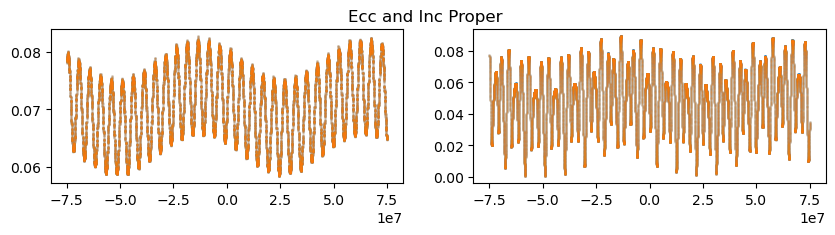

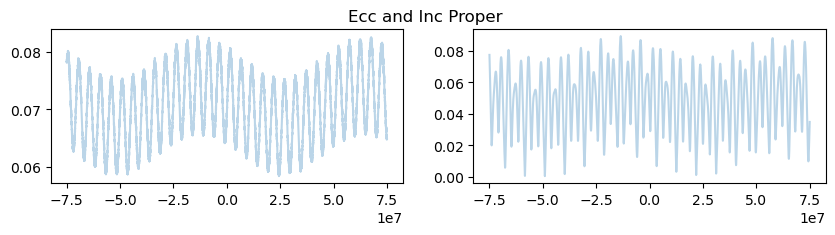

In [4]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2,figsize=(10,2))
ax[0].scatter(time, sb_elems[1], s=1, alpha=0.1)
ax[1].scatter(time, sb_elems[2], s=1, alpha=0.1)
ax[0].scatter(time, np.abs(hk_arr), s=1, alpha=0.1)
ax[1].scatter(time, np.abs(pq_arr), s=1, alpha=0.1)
fig.suptitle('Ecc and Inc Proper')
plt.show()

import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2,figsize=(10,2))
ax[0].plot(time, sb_elems[1],  alpha=0.3)
ax[1].plot(time, sb_elems[2],  alpha=0.3)
#ax[0].plot(time, np.abs(hk_arr),  alpha=0.3)
#ax[1].plot(time, np.abs(pq_arr),  alpha=0.3)
fig.suptitle('Ecc and Inc Proper')
plt.show()

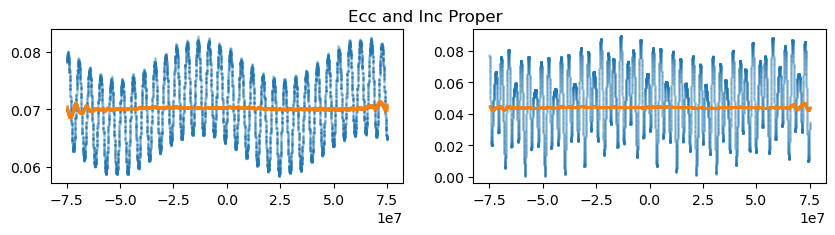

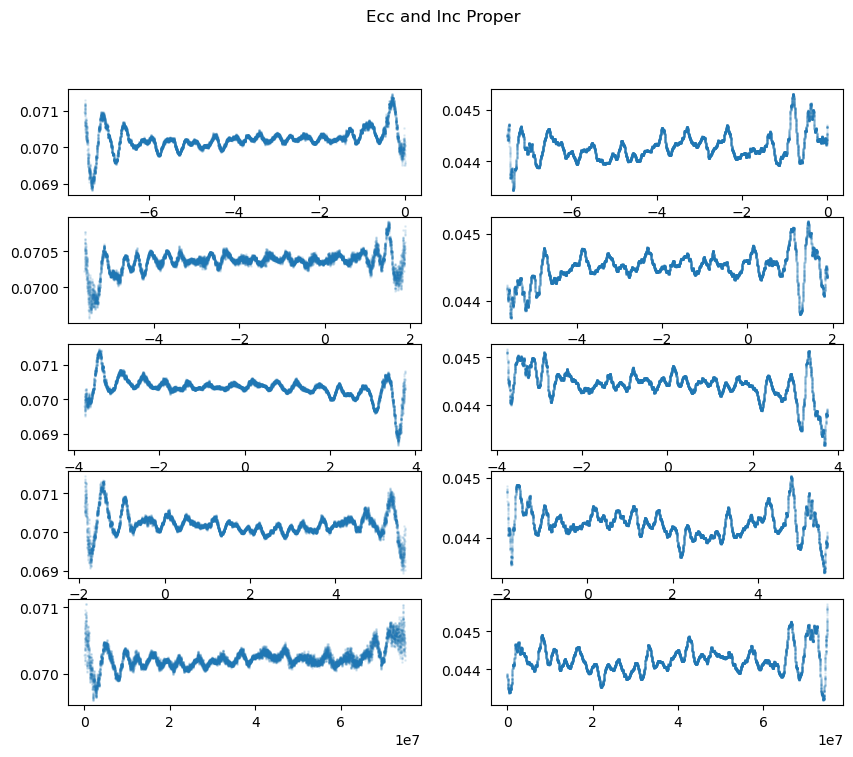

In [5]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2,figsize=(10,2))
ax[0].scatter(time, np.abs(hk_arr), s=1, alpha=0.1)
ax[1].scatter(time, np.abs(pq_arr), s=1, alpha=0.1)
ax[0].scatter(time, np.abs(hk_new), s=1, alpha=0.1)
ax[1].scatter(time, np.abs(pq_new), s=1, alpha=0.1)
fig.suptitle('Ecc and Inc Proper')
plt.show()

num = len(hk_wins)
fig,ax = plt.subplots(num,2,figsize=(10,2*num-2))

for i in range(num):                
    #ax[i,0].plot(tno_result.time, np.abs(tno_result.hk_wins[i]))
    #ax[i,1].plot(tno_result.time, np.abs(tno_result.pq_wins[i]))
    ax[i,0].scatter(t_wins[i],np.abs(hk_wins[i]), s=1, alpha=0.1)
    ax[i,1].scatter(t_wins[i],np.abs(pq_wins[i]), s=1, alpha=0.1)
fig.suptitle('Ecc and Inc Proper')
plt.show()

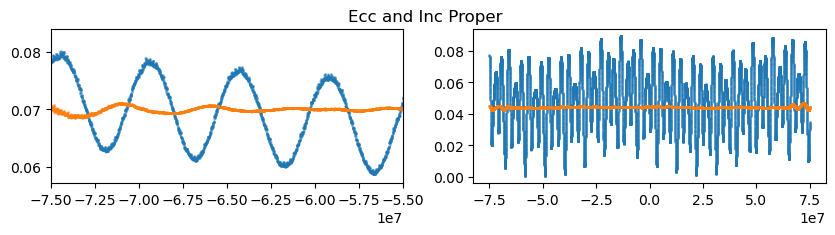

In [6]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2,figsize=(10,2))
ax[0].scatter(time, np.abs(hk_arr), s=1, alpha=0.3)
ax[1].scatter(time, np.abs(pq_arr), s=1, alpha=0.3)
ax[0].scatter(time, np.abs(hk_new), s=1, alpha=0.3)
ax[1].scatter(time, np.abs(pq_new), s=1, alpha=0.3)
ax[0].set_xlim(-7.5e7,-5.5e7)
fig.suptitle('Ecc and Inc Proper')
plt.show()

15001 15001


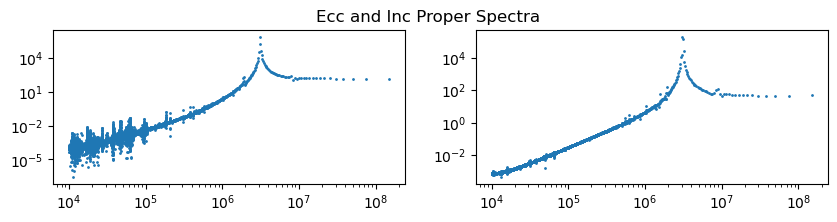

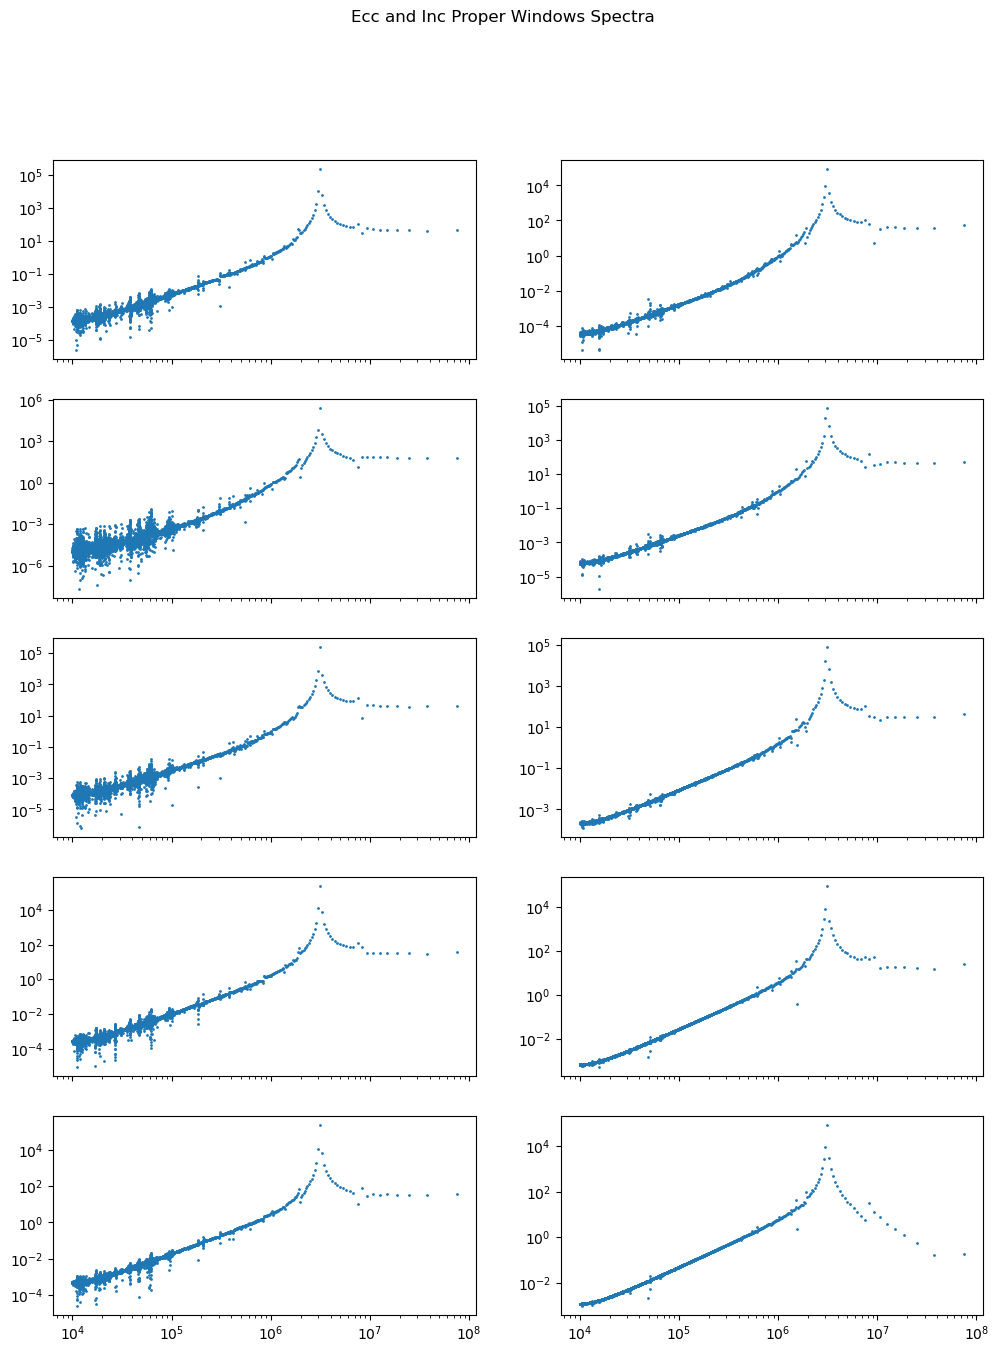

In [7]:
import matplotlib.pyplot as plt
#print(vars(tno_results.proper_
Yhk = np.abs(np.fft.rfft(hk_new))**2
Ypq = np.abs(np.fft.rfft(pq_new))**2
dt = abs(time[-1]-time[-2])
#print(tno_result.time, Yhk)
freq = np.fft.rfftfreq(len(hk_arr), dt)
print(len(freq), len(Yhk))
fig,ax = plt.subplots(1,2,figsize=(10,2), sharex=True)
ax[0].scatter(1/freq, Yhk,s=1)
ax[1].scatter(1/freq, Ypq,s=1)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
fig.suptitle('Ecc and Inc Proper Spectra')
plt.show()

num = len(hk_wins)
fig,ax = plt.subplots(num,2,figsize=(12,3*num), sharex=True)

for i in range(num):    
    Yhks = abs(np.fft.rfft(hk_wins[i]))**2
    Ypqs = abs(np.fft.rfft(pq_wins[i]))**2
    freqs = np.fft.rfftfreq(len(hk_wins[i]), dt)

    #ax[i,0].axvline(1/tno_result.proper_elements.proper_elements['g(rev/yr)'])
    #ax[i,1].axvline(abs(1/tno_result.proper_elements.proper_elements['s(rev/yr)']))
    
    ax[i,0].scatter(1/freqs, Yhks,s=1)
    ax[i,1].scatter(1/freqs, Ypqs,s=1)
    ax[i,0].set_xscale('log')
    ax[i,0].set_yscale('log')
    ax[i,1].set_yscale('log')


fig.suptitle('Ecc and Inc Proper Windows Spectra')
plt.show()

15001 15001


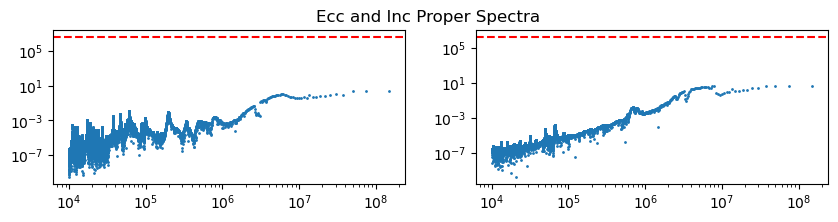

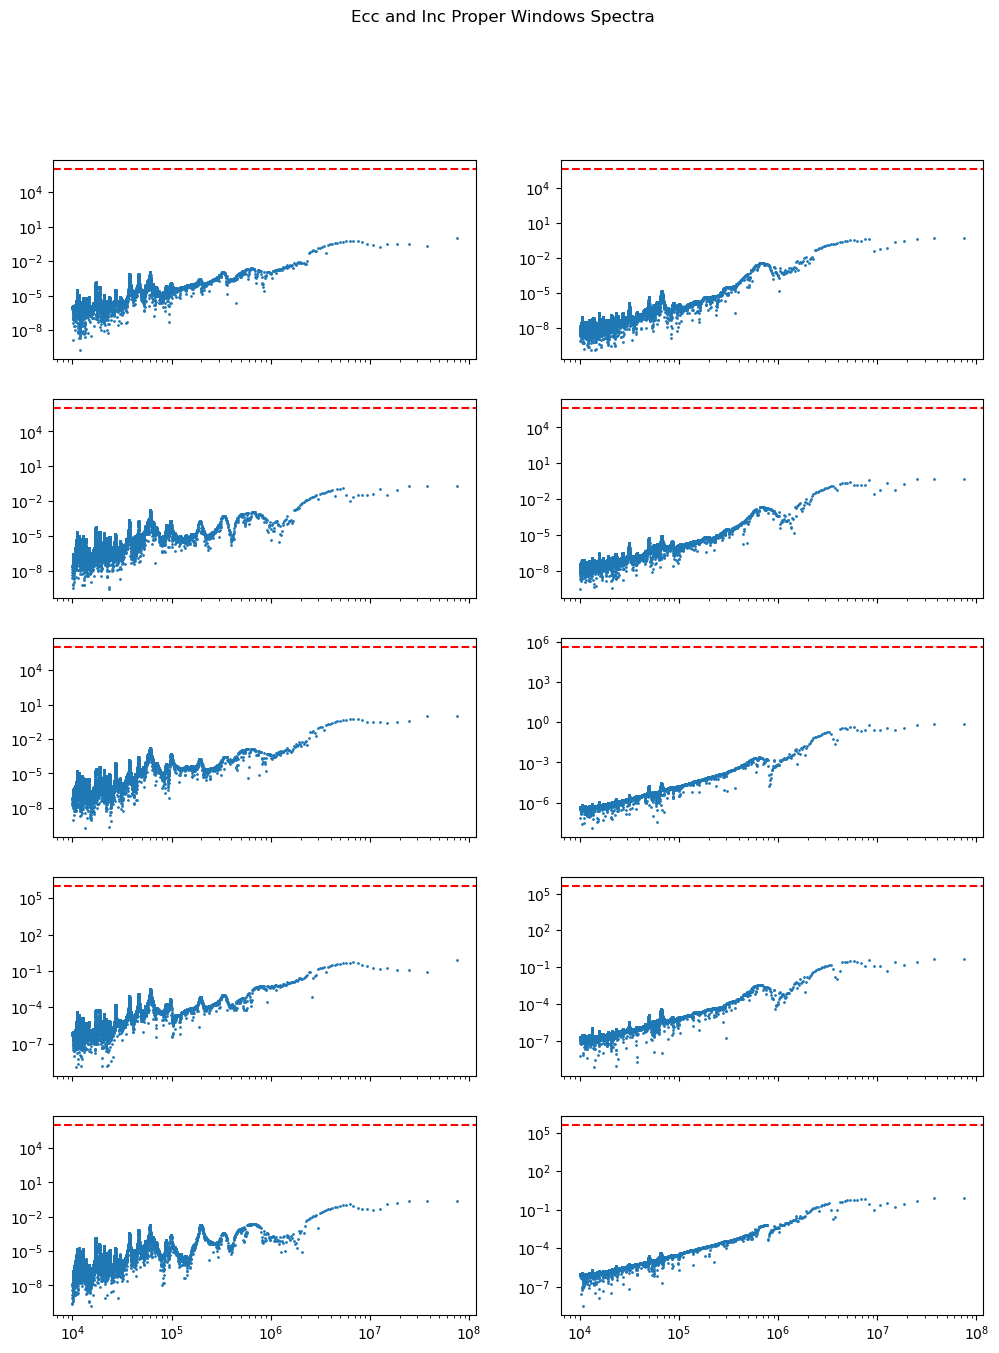

In [8]:
import matplotlib.pyplot as plt

Yhk = np.abs(np.fft.rfft(np.abs(hk_new)))**2
Ypq = np.abs(np.fft.rfft(np.abs(pq_new)))**2
dt = abs(time[-1]-time[-2])
#print(tno_result.time, Yhk)
freq = np.fft.rfftfreq(len(hk_arr), dt)
print(len(freq), len(Yhk))
fig,ax = plt.subplots(1,2,figsize=(10,2), sharex=True)
ax[0].scatter(1/freq, Yhk,s=1)
ax[1].scatter(1/freq, Ypq,s=1)

ax[0].axhline(Yhk[0],ls='--',c='r')
ax[1].axhline(Ypq[0],ls='--',c='r')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
fig.suptitle('Ecc and Inc Proper Spectra')
plt.show()

num = len(hk_wins)
fig,ax = plt.subplots(num,2,figsize=(12,3*num), sharex=True)

for i in range(num):    
    Yhks = abs(np.fft.rfft(np.abs(hk_wins[i])))**2
    Ypqs = abs(np.fft.rfft(np.abs(pq_wins[i])))**2
    freqs = np.fft.rfftfreq(len(hk_wins[i]), dt)
    
    ax[i,0].scatter(1/freqs, Yhks,s=1)
    ax[i,1].scatter(1/freqs, Ypqs,s=1)
    ax[i,0].axhline(Yhks[0],ls='--',c='r')
    ax[i,1].axhline(Ypqs[0],ls='--',c='r')
    ax[i,0].set_xscale('log')
    ax[i,0].set_yscale('log')
    ax[i,1].set_yscale('log')


fig.suptitle('Ecc and Inc Proper Windows Spectra')
plt.show()